In [1]:
from kernels import PhysKerBase, PhysKerGP
from priors import SquExpKernel
from sympy import *
import numpy as np

### 1d HEAT EQUATION

In [2]:
def index_concat(u, f):
    u_indexed = np.column_stack((np.zeros(u.shape[0]), u))
    f_indexed = np.column_stack((np.ones(f.shape[0]), f))

    return np.vstack((u_indexed, f_indexed))

In [3]:
squexp = SquExpKernel(1) # Specifying the prior on u(x,t) ~ GP(0, SquExp)
L = sympify("-a*Derivative(u, x0, 2)") # Specifying the linear operator

# Specifying information about maxima and minima of u(x,t)
boundary_ops = [sympify("-Derivative(u, x0)")]
boundary_conds = [lambda x0: x0 in [0,1]]

phys_kernel = PhysKerBase(squexp, L, boundary_ops, boundary_conds)

In [4]:
phys_kernel.kernel_dictionary()

{'uu': s**2*exp(-w0*(x0 - y0)**2/2),
 'uf': -a*s**2*w0*(w0*(x0 - y0)**2 - 1)*exp(-w0*(x0 - y0)**2/2),
 'fu': -a*s**2*w0*(w0*(x0 - y0)**2 - 1)*exp(-w0*(x0 - y0)**2/2),
 'ff': -a**2*s**2*w0**2*(4*w0*(x0 - y0)**2 - (w0*(x0 - y0)**2 - 1)**2 - 2)*exp(-w0*(x0 - y0)**2/2),
 'ub0': s**2*w0*(2*x0 - 2*y0)*exp(-w0*(x0 - y0)**2/2)/2,
 'b0u': s**2*w0*(-2*x0 + 2*y0)*exp(-w0*(x0 - y0)**2/2)/2,
 'fb0': -a*s**2*w0**2*(2*x0 - 2*y0)*(w0*(x0 - y0)**2 - 1)*exp(-w0*(x0 - y0)**2/2)/2 + a*s**2*w0**2*(2*x0 - 2*y0)*exp(-w0*(x0 - y0)**2/2),
 'b0f': -a*s**2*w0**2*(-2*x0 + 2*y0)*(w0*(x0 - y0)**2 - 1)*exp(-w0*(x0 - y0)**2/2)/2 + a*s**2*w0**2*(-2*x0 + 2*y0)*exp(-w0*(x0 - y0)**2/2),
 'b0b0': s**2*w0**2*(-2*x0 + 2*y0)*(2*x0 - 2*y0)*exp(-w0*(x0 - y0)**2/2)/4 + s**2*w0*exp(-w0*(x0 - y0)**2/2)}

In [5]:
phys_kernel_gp = PhysKerGP(phys_kernel, 
                           {"a":1, "w0":0.5, "s":1.0}, 
                           {"a":(1.0,1.0), "w0":(1e-5,200), "s":(1,1)},
                           sigma=(0.1,1.0))

In [6]:
true_f = np.vectorize(lambda x : (4*np.pi**2)*np.sin(2*np.pi*x))
true_u = np.vectorize(lambda x : np.sin(2*np.pi*x))

In [7]:
np.random.seed(3)

N_u = 2
N_f = 10
u_obs = np.array([0,1])

a,b = 0,1
n_f = N_f-1
indexes = np.arange(0,n_f+1)

# Chebyshev nodes for f observations
f_obs = (a+b)/2 + ((b-a)/2)*np.cos(np.pi*indexes/n_f)

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor

gp = GaussianProcessRegressor(kernel=phys_kernel_gp,
                              random_state=2,
                              alpha=1e-6,
                              n_restarts_optimizer=2)

u_part = np.array([2*np.pi, 2*np.pi])
y = np.hstack((u_part, true_f(f_obs)))
gp.fit(index_concat(u_obs, f_obs), y)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 1)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-06
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary 

In [15]:
gp.kernel_.param_values

{'a': np.float64(1.0),
 'w0': np.float64(7.450995367679122),
 's': np.float64(1.0)}

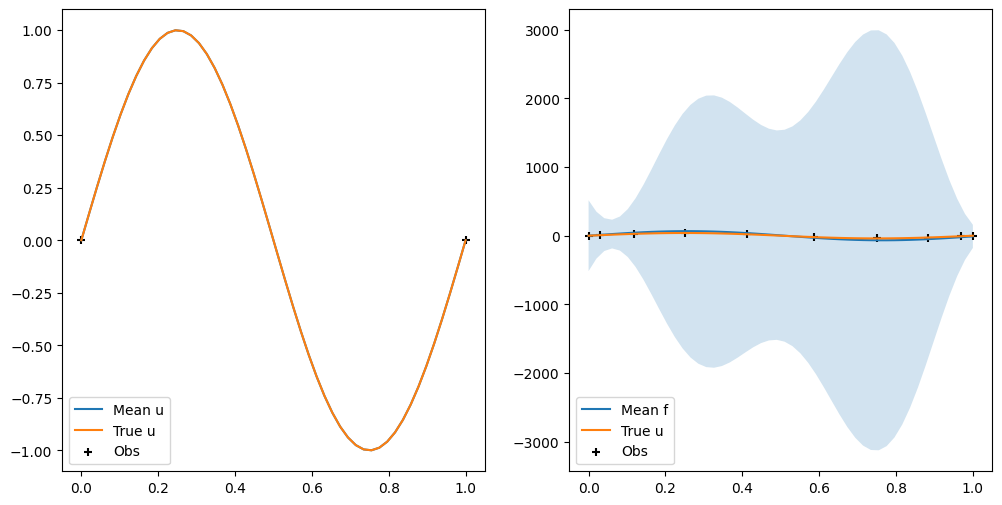

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(12,6))

N_plot = 50
X = np.linspace(0, 1, N_plot)

# U_prediction
u_mean_prediction, u_std_prediction = gp.predict(np.column_stack((np.zeros((N_plot,1)), X)), return_cov=True)
u_std_prediction = np.diagonal(u_std_prediction)
ax[0].plot(X, u_mean_prediction, label="Mean u")
#ax[0].fill_between(X, u_mean_prediction-1.96*u_std_prediction, u_mean_prediction+1.96*u_std_prediction, alpha=0.2)
ax[0].plot(X, true_u(X), label="True u")
ax[0].scatter(u_obs, true_u(u_obs), label="Obs", marker='+', color="black")
ax[0].legend(loc="lower left")

# F_prediction
f_mean_prediction, f_std_prediction = gp.predict(np.column_stack((np.ones((N_plot,1)), X)), return_cov=True)
f_std_prediction = np.diagonal(f_std_prediction)
ax[1].plot(X, f_mean_prediction, label="Mean f")
ax[1].fill_between(X, f_mean_prediction-1.96*f_std_prediction, f_mean_prediction+1.96*f_std_prediction, alpha=0.2)
ax[1].plot(X, true_f(X), label="True u")
ax[1].scatter(f_obs, true_f(f_obs), label="Obs", marker='+', color="black")
ax[1].legend(loc="lower left")

plt.show()

In [11]:
print(phys_kernel.label_matrix((X.reshape(-1,1),np.array([[]])), (np.array([u_obs]).T, np.array([f_obs]).T)))

[['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf' 'uf']
 ['ub0' 'ub0' 'uf' 'uf' '

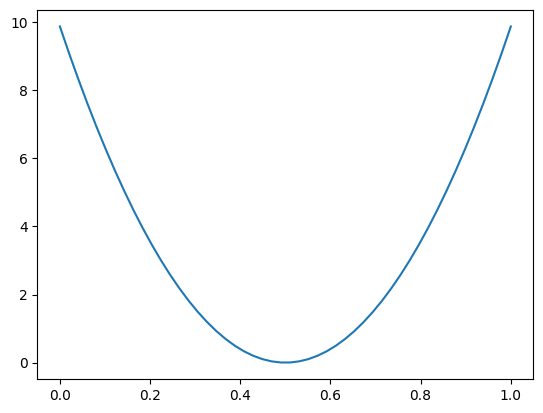

In [12]:
plt.plot(X,abs(true_u(X)-u_mean_prediction)**2)